In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
pi_df = pd.read_csv("performance_data/ollama_biography_results_pi.csv")
rtx_df = pd.read_csv("performance_data/ollama_biography_results_rtx.csv")
mac_df = pd.read_csv("performance_data/ollama_biography_results_mac.csv")


In [21]:
pi_df.columns

Index(['name', 'hardware', 'model', 'prompt', 'full_prompt',
       'generated_biography', 'response_chars', 'response_words',
       'measured_total_time_seconds', 'ollama_total_duration_ns',
       'ollama_load_duration_ns', 'ollama_prompt_eval_count',
       'ollama_prompt_eval_duration_ns', 'ollama_eval_count',
       'ollama_eval_duration_ns', 'ollama_total_duration_sec',
       'ollama_load_duration_sec', 'ollama_prompt_eval_duration_sec',
       'ollama_eval_duration_sec', 'tokens_per_second_eval',
       'tokens_per_second_total', 'tokens_per_second_measured',
       'tokens_per_second_common', 'done', 'done_reason', 'error',
       'raw_response_json', 'original_biography'],
      dtype='str')

In [22]:
rtx_df.columns

Index(['name', 'hardware', 'model', 'prompt', 'generated_biography',
       'response_chars', 'response_words', 'measured_total_time_seconds',
       'ollama_total_duration_ns', 'ollama_load_duration_ns',
       'ollama_prompt_eval_count', 'ollama_prompt_eval_duration_ns',
       'ollama_eval_count', 'ollama_eval_duration_ns', 'tokens_per_second',
       'raw_response_json', 'original_biography'],
      dtype='str')

In [ ]:
mac_df.columns

In [19]:
pi_df.head()

,name,hardware,model,prompt,full_prompt,generated_biography,response_chars,response_words,measured_total_time_seconds,ollama_total_duration_ns,...,ollama_eval_duration_sec,tokens_per_second_eval,tokens_per_second_total,tokens_per_second_measured,tokens_per_second_common,done,done_reason,error,raw_response_json,original_biography
0,Abraham Lincoln,HAILO_10H,qwen2.5-instruct:1.5b,Write a factual biography of the historical fi...,You are a world history assistant. Provide fac...,Abraham Lincoln was the 16th President of the ...,4361,730,148.875393,148842861087,...,NaN,NaN,6.879739,6.878235,6.879739,True,length,NaN,"{""model"": ""qwen2.5-instruct:1.5b"", ""created_at...","Abraham Lincoln (February 12, 1809 – April 15,..."
1,Aristotle,HAILO_10H,qwen2.5-instruct:1.5b,Write a factual biography of the historical fi...,You are a world history assistant. Provide fac...,"Aristotle was a Greek philosopher, scientist, ...",3785,651,148.795685,148749116788,...,NaN,NaN,6.884074,6.881920,6.884074,True,length,NaN,"{""model"": ""qwen2.5-instruct:1.5b"", ""created_at...","Aristotle (Attic Greek: Ἀριστοτέλης, romanized..."
2,Albert Einstein,HAILO_10H,qwen2.5-instruct:1.5b,Write a factual biography of the historical fi...,You are a world history assistant. Provide fac...,Albert Einstein was a German theoretical physi...,757,123,24.211587,24169286115,...,NaN,NaN,6.785471,6.773616,6.785471,True,stop,NaN,"{""model"": ""qwen2.5-instruct:1.5b"", ""created_at...",Albert Einstein (14 March 1879 – 18 April 1955...
3,Alexander the Great,HAILO_10H,qwen2.5-instruct:1.5b,Write a factual biography of the historical fi...,You are a world history assistant. Provide fac...,Alexander the Great was a Macedon king who liv...,719,114,21.708889,21674585989,...,NaN,NaN,6.782136,6.771420,6.782136,True,stop,NaN,"{""model"": ""qwen2.5-instruct:1.5b"", ""created_at...",Alexander III of Macedon (Ancient Greek: Ἀλέξα...
4,Ada Lovelace,HAILO_10H,qwen2.5-instruct:1.5b,Write a factual biography of the historical fi...,You are a world history assistant. Provide fac...,"Ada Lovelace, born Augusta Ada Byron Charles A...",1008,168,36.415966,36369694307,...,NaN,NaN,6.818864,6.810200,6.818864,True,stop,NaN,"{""model"": ""qwen2.5-instruct:1.5b"", ""created_at...","Augusta Ada King, Countess of Lovelace (née By..."


In [7]:
rtx_df.head()

,name,hardware,model,prompt,generated_biography,response_chars,response_words,measured_total_time_seconds,ollama_total_duration_ns,ollama_load_duration_ns,ollama_prompt_eval_count,ollama_prompt_eval_duration_ns,ollama_eval_count,ollama_eval_duration_ns,tokens_per_second,raw_response_json,original_biography
0,Abraham Lincoln,rtx_5070_ubuntu,qwen2.5:1.5b,Write a factual biography of the historical fi...,Abraham Lincoln was an American statesman and ...,1244,199,28.974863,28972942018,27837491716,77,18059262,274,978472083,280.028429,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...","Abraham Lincoln (February 12, 1809 – April 15,..."
1,Aristotle,rtx_5070_ubuntu,qwen2.5:1.5b,Write a factual biography of the historical fi...,"Aristotle was a Greek polymath, philosopher, a...",1592,238,1.453317,1452129345,56515472,76,17438350,333,1213457314,274.422508,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...","Aristotle (Attic Greek: Ἀριστοτέλης, romanized..."
2,Albert Einstein,rtx_5070_ubuntu,qwen2.5:1.5b,Write a factual biography of the historical fi...,Albert Einstein was a German-born theoretical ...,1594,247,1.430520,1429509101,54898535,77,15108980,329,1198470212,274.516627,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...",Albert Einstein (14 March 1879 – 18 April 1955...
3,Alexander the Great,rtx_5070_ubuntu,qwen2.5:1.5b,Write a factual biography of the historical fi...,"Alexander III of Macedon, commonly known as Al...",2769,431,2.581411,2580440056,55329547,78,11847513,609,2219380441,274.400904,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...",Alexander III of Macedon (Ancient Greek: Ἀλέξα...
4,Ada Lovelace,rtx_5070_ubuntu,qwen2.5:1.5b,Write a factual biography of the historical fi...,Ada Lovelace was an English mathematician and ...,1549,244,1.365669,1364701179,57174132,79,13091471,320,1156658886,276.658922,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...","Augusta Ada King, Countess of Lovelace (née By..."


In [8]:
mac_df.head()

,name,hardware,model,prompt,generated_biography,response_chars,response_words,measured_total_time_seconds,ollama_total_duration_ns,ollama_load_duration_ns,ollama_prompt_eval_count,ollama_prompt_eval_duration_ns,ollama_eval_count,ollama_eval_duration_ns,tokens_per_second,raw_response_json,original_biography
0,Abraham Lincoln,macbook_pro_m4,qwen2.5:1.5b,Write a factual biography of the historical fi...,Abraham Lincoln was an American statesman and ...,2309,372,7.708681,7699885208,1241946541,77,188021000,510,6115541085,83.394093,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...","Abraham Lincoln (February 12, 1809 – April 15,..."
1,Aristotle,macbook_pro_m4,qwen2.5:1.5b,Write a factual biography of the historical fi...,"Aristotle was a Greek polymath, philosopher, a...",1637,239,4.220854,4217038000,45166125,76,63690625,338,4005539667,84.383136,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...","Aristotle (Attic Greek: Ἀριστοτέλης, romanized..."
2,Albert Einstein,macbook_pro_m4,qwen2.5:1.5b,Write a factual biography of the historical fi...,Albert Einstein was a German-born theoretical ...,2649,405,6.265154,6261315666,47302458,77,61789000,506,5996114399,84.387983,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...",Albert Einstein (14 March 1879 – 18 April 1955...
3,Alexander the Great,macbook_pro_m4,qwen2.5:1.5b,Write a factual biography of the historical fi...,"Alexander III of Macedon, commonly known as Al...",2240,355,6.232225,6222676041,59763958,78,61793250,489,5944540547,82.260352,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...",Alexander III of Macedon (Ancient Greek: Ἀλέξα...
4,Ada Lovelace,macbook_pro_m4,qwen2.5:1.5b,Write a factual biography of the historical fi...,Ada Lovelace was an English mathematician and ...,1531,241,4.109479,4100636416,74094833,79,65987125,317,3847761829,82.385557,"{""model"": ""qwen2.5:1.5b"", ""created_at"": ""2026-...","Augusta Ada King, Countess of Lovelace (née By..."


In [26]:
mac_df = mac_df.iloc[2:].reset_index(drop=True)
rtx_df = rtx_df.iloc[2:].reset_index(drop=True)
pi_df = pi_df.iloc[2:].reset_index(drop=True)

In [27]:
all_results = pd.concat([rtx_df, mac_df], ignore_index=True)

In [28]:
all_results["ollama_total_duration_sec"] = all_results["ollama_total_duration_ns"] / 1e9
all_results["tokens_per_second_total"] = (
    all_results["ollama_eval_count"] / all_results["ollama_total_duration_sec"]
)

all_results["tokens_per_second_common"] = all_results["tokens_per_second"].fillna(
    all_results["tokens_per_second_total"]
)

In [29]:
all_results = pd.concat([pi_df,all_results], ignore_index=True)


# Bar plot for average tokens/sec
## Which hardware generates text the fastest?

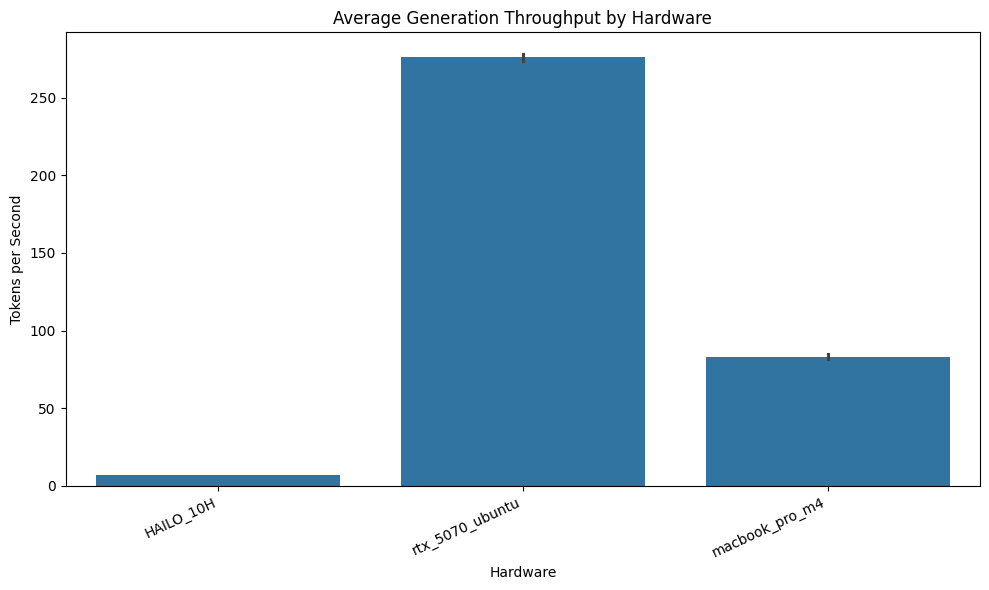

In [30]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_results,
    x="hardware",
    y="tokens_per_second_common",
    errorbar="sd"
)

plt.title("Average Generation Throughput by Hardware")
plt.xlabel("Hardware")
plt.ylabel("Tokens per Second")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Bar plot for average latency
## Which hardware responds the fastest?

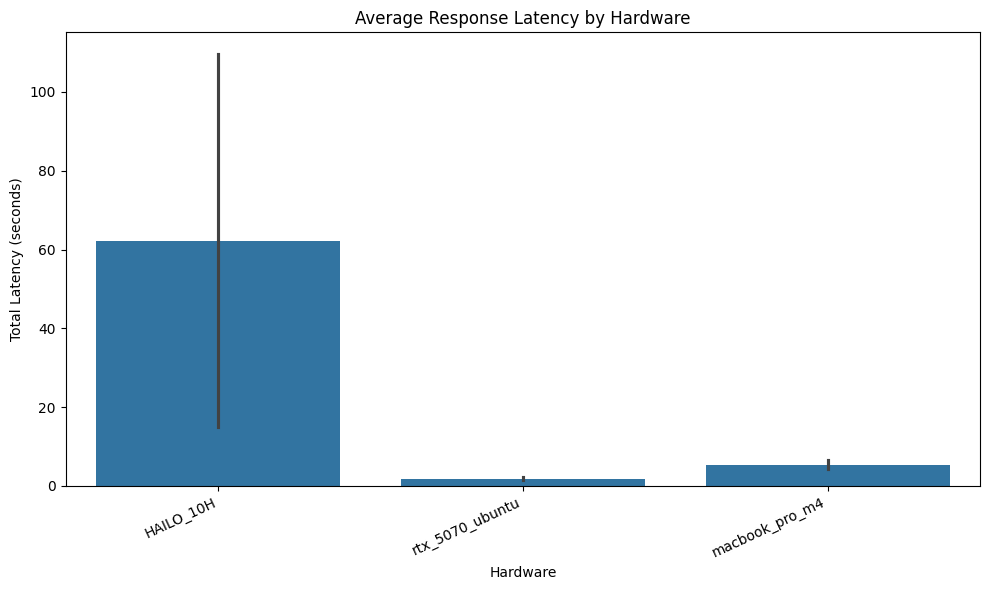

In [31]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_results,
    x="hardware",
    y="measured_total_time_seconds",
    errorbar="sd"
)

plt.title("Average Response Latency by Hardware")
plt.xlabel("Hardware")
plt.ylabel("Total Latency (seconds)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

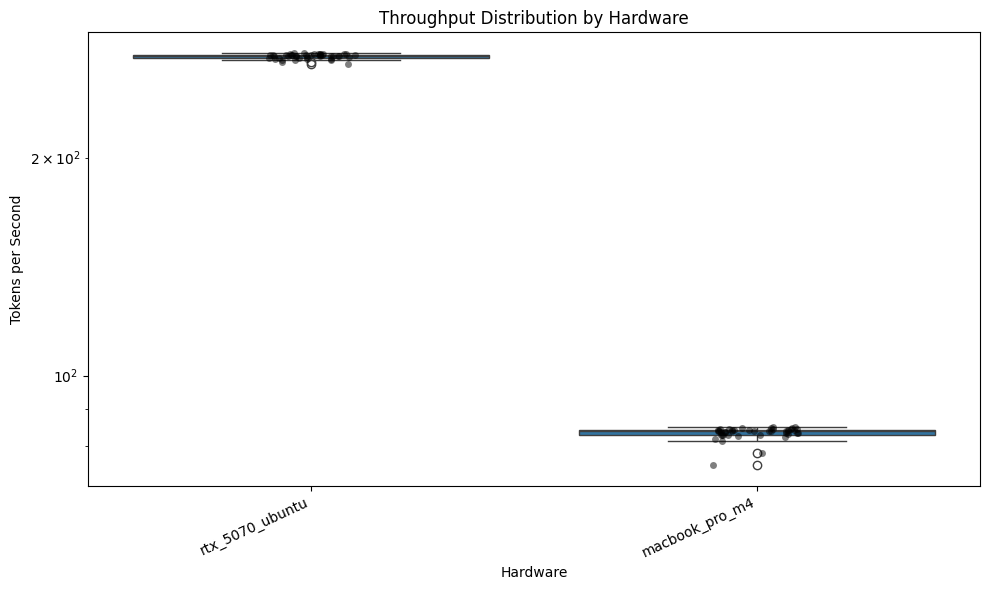

In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=all_results,
    x="hardware",
    y="tokens_per_second_common"
)

sns.stripplot(
    data=all_results,
    x="hardware",
    y="tokens_per_second_common",
    color="black",
    alpha=0.5,
    jitter=True
)
# plt.yscale("log")
plt.title("Throughput Distribution by Hardware")
plt.xlabel("Hardware")
plt.ylabel("Tokens per Second")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()